In [64]:
# ============================================================
# İSTANBUL 39 İLÇE SU TÜKETİM TAHMİNİ - TimeGPT
# Konut ve işyeri ayrı ayrı tahmin edilir, sonra toplanır
# ============================================================


# ── AŞAMA 1: KÜTÜPHANELERİ İÇE AKTAR ──────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nixtla import NixtlaClient
import warnings
warnings.filterwarnings("ignore")

print("✅ Kütüphaneler yüklendi")

✅ Kütüphaneler yüklendi


In [82]:
# ── AŞAMA 2: DOSYA YOLLARI ─────────────────────────────────
ABONE_DOSYA    = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\abone.xlsx"
SU_DOSYA       = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\su_tuketim.xlsx"
SICAKLIK_DOSYA = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\sicaklik.xlsx"


In [83]:
# ── AŞAMA 3: YARDIMCI FONKSİYON - TARİH PARSE ─────────────
AYLAR_TR = {
    "Ocak":1, "Şubat":2, "Mart":3, "Nisan":4,
    "Mayıs":5, "Haziran":6, "Temmuz":7, "Ağustos":8,
    "Eylül":9, "Ekim":10, "Kasım":11, "Aralık":12
}

def tarih_parse(tarih_str):
    parcalar = str(tarih_str).strip().split()
    yil = int(parcalar[0])
    ay  = AYLAR_TR[parcalar[-1]]
    return pd.Timestamp(year=yil, month=ay, day=1)

In [84]:
# ── AŞAMA 4: ABONE VERİSİNİ YÜKLE ──────────────────────────
abone_raw = pd.read_excel(ABONE_DOSYA, header=1)

konut = abone_raw.iloc[:, 0:3].copy()
konut.columns = ["ilce", "tarih", "konut_abone"]

isyeri = abone_raw.iloc[:, 8:11].copy()
isyeri.columns = ["ilce", "tarih", "isyeri_abone"]

konut  = konut.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)
isyeri = isyeri.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)

konut["tarih"]  = konut["tarih"].apply(tarih_parse)
isyeri["tarih"] = isyeri["tarih"].apply(tarih_parse)

abone_df = pd.merge(konut, isyeri, on=["ilce", "tarih"], how="outer")
abone_df = abone_df[["ilce", "tarih", "konut_abone", "isyeri_abone"]]

print(f"✅ Abone verisi: {abone_df.shape[0]} satır, {abone_df['ilce'].nunique()} ilçe")

✅ Abone verisi: 2808 satır, 39 ilçe


In [85]:
# ── AŞAMA 5: SU TÜKETİM VERİSİNİ YÜKLE ────────────────────
su_raw = pd.read_excel(SU_DOSYA, header=1)

konut_su = su_raw.iloc[:, 0:3].copy()
konut_su.columns = ["ilce", "tarih", "konut_m3"]

isyeri_su = su_raw.iloc[:, 4:7].copy()
isyeri_su.columns = ["ilce", "tarih", "isyeri_m3"]

konut_su  = konut_su.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)
isyeri_su = isyeri_su.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)

konut_su["tarih"]  = konut_su["tarih"].apply(tarih_parse)
isyeri_su["tarih"] = isyeri_su["tarih"].apply(tarih_parse)

konut_su["konut_m3"]   = pd.to_numeric(konut_su["konut_m3"],   errors="coerce")
isyeri_su["isyeri_m3"] = pd.to_numeric(isyeri_su["isyeri_m3"], errors="coerce")

su_df = pd.merge(konut_su, isyeri_su, on=["ilce", "tarih"], how="outer")
su_df = su_df[["ilce", "tarih", "konut_m3", "isyeri_m3"]]

print(f"✅ Su tüketim verisi: {su_df.shape[0]} satır, {su_df['ilce'].nunique()} ilçe")

✅ Su tüketim verisi: 2808 satır, 39 ilçe


In [86]:
# ── AŞAMA 6: SICAKLIK VERİSİNİ YÜKLE ───────────────────────
# header=1 → 2. satırı başlık olarak oku (ilk satır boş)
sicaklik_raw = pd.read_excel(SICAKLIK_DOSYA, header=1)

sicaklik_df = sicaklik_raw.rename(columns={
    "İLÇE": "ilce",
    "TARİH": "tarih",
    "ORTALAMA SICAKLIK": "sicaklik_c"
})

# "2020   Ocak" → datetime
tarih_split = sicaklik_df["tarih"].astype(str).str.strip().str.split(r"\s+", expand=True)
sicaklik_df["tarih"] = pd.to_datetime(
    tarih_split[0] + "-" + tarih_split[1].map(AYLAR_TR).astype(str),
    format="%Y-%m"
)

sicaklik_df["sicaklik_c"] = (
    sicaklik_df["sicaklik_c"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

sicaklik_df["ilce"] = sicaklik_df["ilce"].str.upper().str.strip()

print(f"✅ Sıcaklık verisi: {sicaklik_df.shape[0]} satır, {sicaklik_df['ilce'].nunique()} ilçe")

✅ Sıcaklık verisi: 2808 satır, 39 ilçe


In [87]:
#eşleşmeyen ilçeler
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_abone    = set(abone_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())

print(f"Su verisi      : {len(ilce_su)} ilçe")
print(f"Abone verisi   : {len(ilce_abone)} ilçe")
print(f"Sıcaklık verisi: {len(ilce_sicaklik)} ilçe")

print("\n── Su ∩ Abone ──────────────────────────────")
print("🔴 Abonede olup suda OLMAYAN  :", ilce_abone - ilce_su)
print("🔵 Suda olup abonede OLMAYAN  :", ilce_su - ilce_abone)

print("\n── Su ∩ Sıcaklık ───────────────────────────")
print("🔴 Sıcaklıkta olup suda OLMAYAN  :", ilce_sicaklik - ilce_su)
print("🔵 Suda olup sıcaklıkta OLMAYAN  :", ilce_su - ilce_sicaklik)

print("\n── Üç sette birden olan ilçe sayısı ────────")
print("✅", len(ilce_su & ilce_abone & ilce_sicaklik), "ilçe tam eşleşiyor")

print("\n── Üç setten herhangi birinde eksik olanlar ─")
tum_ilceler = ilce_su | ilce_abone | ilce_sicaklik
eksik = {i: [] for i in tum_ilceler}
for i in tum_ilceler:
    if i not in ilce_su:       eksik[i].append("su yok")
    if i not in ilce_abone:    eksik[i].append("abone yok")
    if i not in ilce_sicaklik: eksik[i].append("sıcaklık yok")
eksik = {k: v for k, v in eksik.items() if v}
for ilce, sorun in sorted(eksik.items()):
    print(f"  {ilce:25s} → {', '.join(sorun)}")

Su verisi      : 39 ilçe
Abone verisi   : 39 ilçe
Sıcaklık verisi: 39 ilçe

── Su ∩ Abone ──────────────────────────────
🔴 Abonede olup suda OLMAYAN  : set()
🔵 Suda olup abonede OLMAYAN  : set()

── Su ∩ Sıcaklık ───────────────────────────
🔴 Sıcaklıkta olup suda OLMAYAN  : set()
🔵 Suda olup sıcaklıkta OLMAYAN  : set()

── Üç sette birden olan ilçe sayısı ────────
✅ 39 ilçe tam eşleşiyor

── Üç setten herhangi birinde eksik olanlar ─


In [88]:
# Aşama 7 sonrası doğrulama
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())
eksik = ilce_sicaklik - ilce_su
if eksik:
    print(f"⚠️  Hâlâ eşleşmeyen {len(eksik)} ilçe var: {eksik}")
else:
    print("✅ Tüm 39 ilçe eşleşiyor, devam edilebilir")



✅ Tüm 39 ilçe eşleşiyor, devam edilebilir


In [89]:
# ── AŞAMA 8: ÜÇ VERİYİ BİRLEŞTİR ──────────────────────────
df = (
    su_df
    .merge(abone_df,    on=["ilce", "tarih"], how="inner")
    .merge(sicaklik_df, on=["ilce", "tarih"], how="inner")
)

df = df[["ilce", "tarih",
         "konut_m3", "isyeri_m3",
         "konut_abone", "isyeri_abone",
         "sicaklik_c"]]

df["yil"] = df["tarih"].dt.year
df["ay"]  = df["tarih"].dt.month
df["su_tuketimi_m3"] = df["konut_m3"] + df["isyeri_m3"]

print(f"✅ Birleşik veri: {df.shape[0]} satır, {df['ilce'].nunique()} ilçe")
print(f"📅 Tarih aralığı: {df['tarih'].min().strftime('%Y-%m')} → {df['tarih'].max().strftime('%Y-%m')}")


✅ Birleşik veri: 2808 satır, 39 ilçe
📅 Tarih aralığı: 2020-01 → 2025-12


In [90]:
# ── AŞAMA 9: KEŞİFÇİ ANALİZ ────────────────────────────────
print("\n📊 GENEL İSTATİSTİKLER")
df["su_tuketimi_m3"] = df["konut_m3"] + df["isyeri_m3"]
print(df[["su_tuketimi_m3", "konut_m3", "isyeri_m3", "sicaklik_c"]].describe().round(2))

ilce_ort = df.groupby("ilce")["su_tuketimi_m3"].mean().sort_values(ascending=False)
print("\n🏆 EN ÇOK TÜKETİM (aylık ortalama m³):")
print(ilce_ort.head(5).apply(lambda x: f"{x:,.0f}").to_string())

yillik = df.groupby("yil")["su_tuketimi_m3"].sum()
print("\n📅 YILLIK TOPLAM TÜKETİM:")
print(yillik.apply(lambda x: f"{x:,.0f}").to_string())


📊 GENEL İSTATİSTİKLER
       su_tuketimi_m3    konut_m3   isyeri_m3  sicaklik_c
count         2808.00     2808.00     2808.00     2808.00
mean       1916492.43  1475069.18   441423.25       16.14
std         915371.40   724748.78   297589.20        6.72
min          22357.00    16817.00     2948.00        3.24
25%        1324871.75   958896.25   246765.50       10.13
50%        1842157.50  1428302.00   392879.50       15.77
75%        2362685.75  1872815.00   583546.00       22.51
max        6613796.00  4609887.00  5189876.00       28.28

🏆 EN ÇOK TÜKETİM (aylık ortalama m³):
ilce
ESENYURT     4,693,414
K.ÇEKMECE    3,327,449
PENDİK       3,286,926
ÜMRANİYE     3,191,811
BAĞCILAR     3,051,400

📅 YILLIK TOPLAM TÜKETİM:
yil
2020    857,292,555
2021    842,827,358
2022    901,007,924
2023    911,272,787
2024    944,775,278
2025    924,334,837


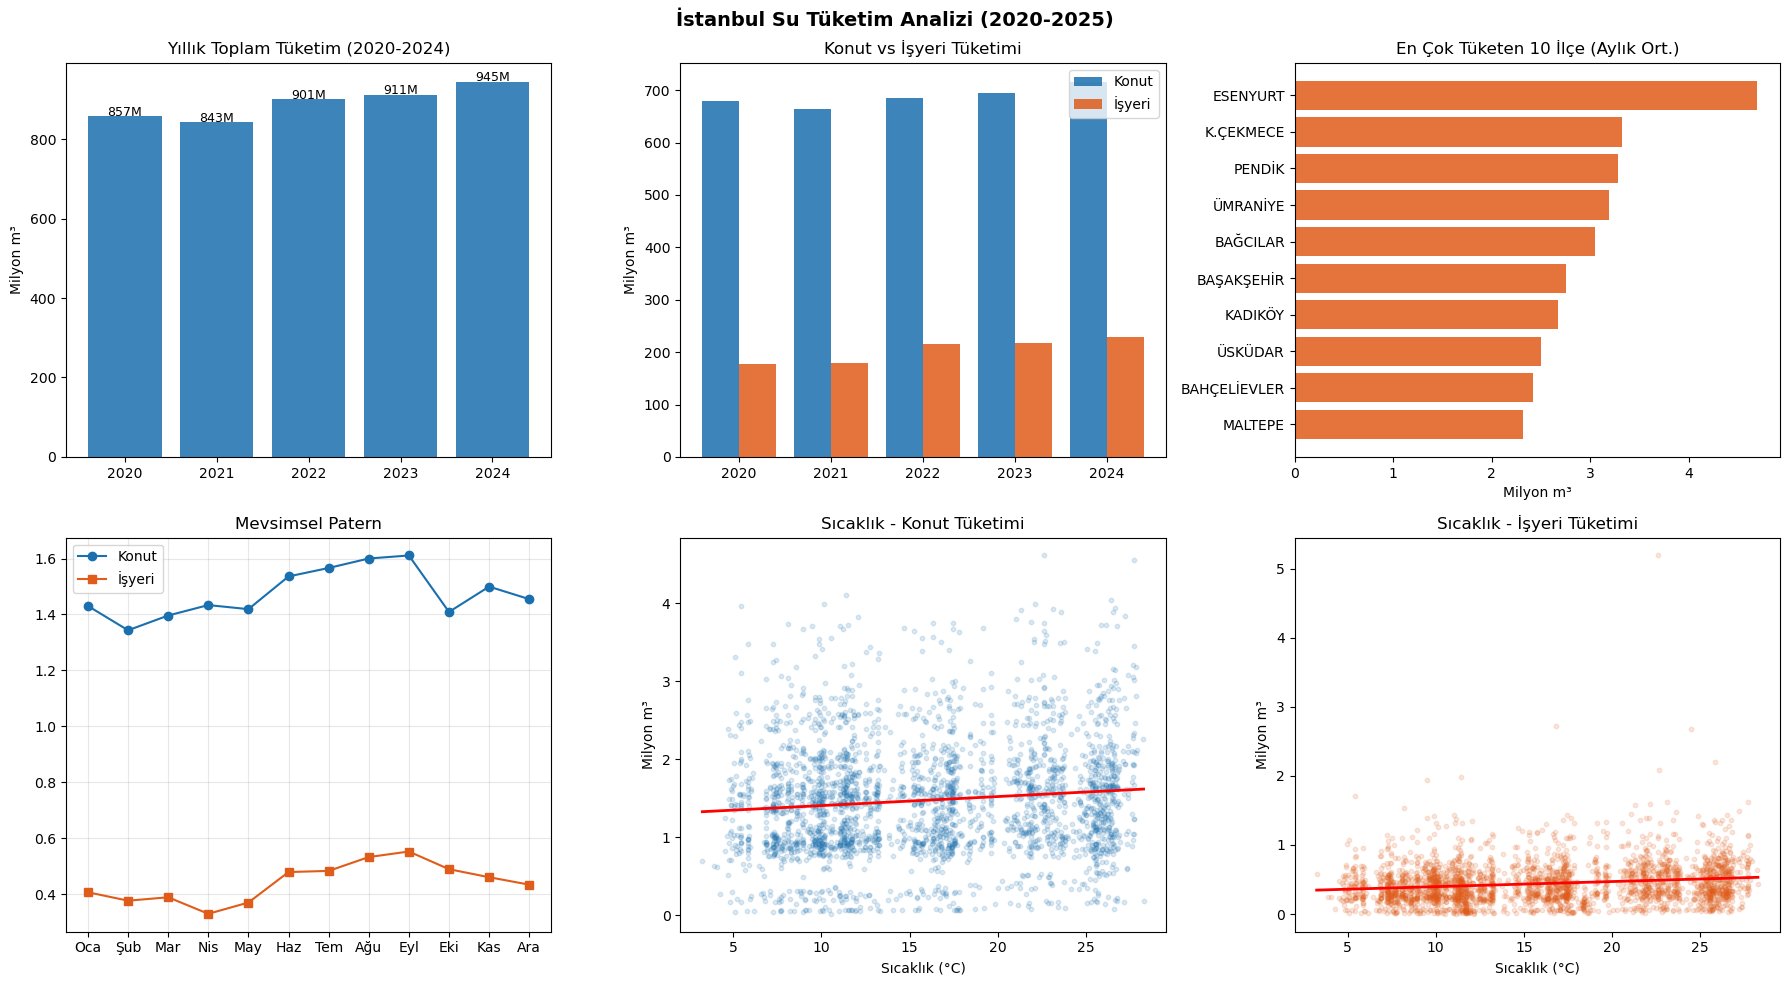

✅ Grafik kaydedildi: analiz.png


In [91]:
# ── AŞAMA 10: KEŞİFÇİ GRAFİKLER ───────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("İstanbul Su Tüketim Analizi (2020-2025)", fontsize=14, fontweight="bold")

# 1. Yıllık toplam tüketim
ax1 = axes[0, 0]
yillik_tam = df[df["yil"] < 2025].groupby("yil")["su_tuketimi_m3"].sum() / 1e6

ax1.bar(yillik_tam.index, yillik_tam.values, color="#1a6fae", alpha=0.85)
ax1.set_title("Yıllık Toplam Tüketim (2020-2024)")
ax1.set_ylabel("Milyon m³")
ax1.set_xticks(yillik_tam.index)

for i, v in enumerate(yillik_tam.values):
    ax1.text(yillik_tam.index[i], v + 1, f"{v:.0f}M", ha="center", fontsize=9)

# 2. Konut vs işyeri
ax2 = axes[0, 1]
yillik_konut  = df[df["yil"] < 2025].groupby("yil")["konut_m3"].sum() / 1e6
yillik_isyeri = df[df["yil"] < 2025].groupby("yil")["isyeri_m3"].sum() / 1e6

x = np.arange(len(yillik_konut))

ax2.bar(x - 0.2, yillik_konut.values, width=0.4, label="Konut", color="#1a6fae", alpha=0.85)
ax2.bar(x + 0.2, yillik_isyeri.values, width=0.4, label="İşyeri", color="#e05c1a", alpha=0.85)

ax2.set_title("Konut vs İşyeri Tüketimi")
ax2.set_ylabel("Milyon m³")
ax2.set_xticks(x)
ax2.set_xticklabels(yillik_konut.index)
ax2.legend()

# 3. İlçeler
ax3 = axes[0, 2]
top10 = ilce_ort.head(10) / 1e6
ax3.barh(top10.index[::-1], top10.values[::-1], color="#e05c1a", alpha=0.85)
ax3.set_title("En Çok Tüketen 10 İlçe (Aylık Ort.)")
ax3.set_xlabel("Milyon m³")

# 4. Mevsimsellik
ax4 = axes[1, 0]
aylik_konut  = df.groupby("ay")["konut_m3"].mean() / 1e6
aylik_isyeri = df.groupby("ay")["isyeri_m3"].mean() / 1e6

ay_isimleri = ["Oca","Şub","Mar","Nis","May","Haz","Tem","Ağu","Eyl","Eki","Kas","Ara"]

ax4.plot(aylik_konut.index, aylik_konut.values, color="#1a6fae", marker="o", label="Konut")
ax4.plot(aylik_isyeri.index, aylik_isyeri.values, color="#e05c1a", marker="s", label="İşyeri")

ax4.set_title("Mevsimsel Patern")
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(ay_isimleri)
ax4.legend()
ax4.grid(True, alpha=0.3)

# ─────────────────────────────────────────────
# 5. Sıcaklık - Konut (DÜZELTİLDİ)
# ─────────────────────────────────────────────

ax5 = axes[1, 1]

x1 = pd.to_numeric(df["sicaklik_c"], errors="coerce")
y1 = pd.to_numeric(df["konut_m3"], errors="coerce") / 1e6

mask1 = np.isfinite(x1) & np.isfinite(y1)
x1 = x1[mask1]
y1 = y1[mask1]

ax5.scatter(x1, y1, alpha=0.15, color="#1a6fae", s=10)
ax5.set_title("Sıcaklık - Konut Tüketimi")
ax5.set_xlabel("Sıcaklık (°C)")
ax5.set_ylabel("Milyon m³")

if len(x1) > 1:
    z = np.polyfit(x1, y1, 1)
    xp = np.linspace(x1.min(), x1.max(), 100)
    ax5.plot(xp, np.poly1d(z)(xp), color="red", linewidth=2)

# ─────────────────────────────────────────────
# 6. Sıcaklık - İşyeri (DÜZELTİLDİ)
# ─────────────────────────────────────────────

ax6 = axes[1, 2]

x2 = pd.to_numeric(df["sicaklik_c"], errors="coerce")
y2 = pd.to_numeric(df["isyeri_m3"], errors="coerce") / 1e6

mask2 = np.isfinite(x2) & np.isfinite(y2)
x2 = x2[mask2]
y2 = y2[mask2]

ax6.scatter(x2, y2, alpha=0.15, color="#e05c1a", s=10)
ax6.set_title("Sıcaklık - İşyeri Tüketimi")
ax6.set_xlabel("Sıcaklık (°C)")
ax6.set_ylabel("Milyon m³")

if len(x2) > 1:
    z2 = np.polyfit(x2, y2, 1)
    xp2 = np.linspace(x2.min(), x2.max(), 100)
    ax6.plot(xp2, np.poly1d(z2)(xp2), color="red", linewidth=2)

# ─────────────────────────────────────────────

plt.tight_layout()
plt.savefig("analiz.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Grafik kaydedildi: analiz.png")

In [92]:
# ── AŞAMA 11: NİXTLA BAĞLANTISI ────────────────────────────
NIXTLA_API_KEY = "nixak-b901265e9a67b4cb541a0b4fdbb477728bbec5faa363f1bc697fa6096881b88ebee17d4ec91d3fcd"

client = NixtlaClient(api_key="nixak-b901265e9a67b4cb541a0b4fdbb477728bbec5faa363f1bc697fa6096881b88ebee17d4ec91d3fcd")
client.validate_api_key()
print("✅ Nixtla API bağlantısı doğrulandı")

INFO:nixtla.nixtla_client:Happy Forecasting! :)


✅ Nixtla API bağlantısı doğrulandı


In [93]:
# ── AŞAMA 12: TİMEGPT FORMATINA ÇEVİR ─────────────────────
def timegpt_hazirla(df, hedef_col, context_bitis="2024-12-01"):
    df_tgpt = df[["ilce", "tarih", hedef_col,
                  "sicaklik_c", "konut_abone", "isyeri_abone"]].copy()
    df_tgpt = df_tgpt.rename(columns={
        "ilce"    : "unique_id",
        "tarih"   : "ds",
        hedef_col : "y"
    })
    df_ctx = df_tgpt[df_tgpt["ds"] <= context_bitis].copy()
    df_val = df_tgpt[df_tgpt["ds"] >  context_bitis].copy()
    return df_ctx, df_val

df_ctx_konut,  df_val_konut  = timegpt_hazirla(df, "konut_m3")
df_ctx_isyeri, df_val_isyeri = timegpt_hazirla(df, "isyeri_m3")
print(f"✅ Konut   bağlam: {df_ctx_konut['ds'].min().strftime('%Y-%m')} → {df_ctx_konut['ds'].max().strftime('%Y-%m')}")
print(f"✅ İşyeri  bağlam: {df_ctx_isyeri['ds'].min().strftime('%Y-%m')} → {df_ctx_isyeri['ds'].max().strftime('%Y-%m')}")

✅ Konut   bağlam: 2020-01 → 2024-12
✅ İşyeri  bağlam: 2020-01 → 2024-12


In [94]:
# ── AŞAMA 13: EKSİK TARİHLERİ DOLDUR ──────────────────────
def tarihleri_tamamla(df_in, baslangic, bitis):
    tam_tarih = pd.date_range(start=baslangic, end=bitis, freq="MS")
    sonuc = []
    for ilce in df_in["unique_id"].unique():
        ilce_df = df_in[df_in["unique_id"] == ilce].set_index("ds")
        ilce_df = ilce_df.reindex(tam_tarih)
        ilce_df["unique_id"] = ilce
        ilce_df.index.name = "ds"
        ilce_df = ilce_df.reset_index()
        for col in ["y", "sicaklik_c", "konut_abone", "isyeri_abone"]:
            ilce_df[col] = ilce_df[col].interpolate(method="linear").ffill().bfill()
        sonuc.append(ilce_df)
    return pd.concat(sonuc).reset_index(drop=True)

# Bağlam: 2020-01 → 2024-12 (eğitim verisi)
df_ctx_konut_tam  = tarihleri_tamamla(df_ctx_konut,  "2020-01-01", "2024-12-01")
df_ctx_isyeri_tam = tarihleri_tamamla(df_ctx_isyeri, "2020-01-01", "2024-12-01")

# Validasyon: 2025-01 → 2025-12 (Aralık dahil, "2025-12-01" yeterli)
df_val_konut_tam  = tarihleri_tamamla(df_val_konut,  "2025-01-01", "2025-12-01")  # ← düzeltildi
df_val_isyeri_tam = tarihleri_tamamla(df_val_isyeri, "2025-01-01", "2025-12-01")  # ← düzeltildi

print(f"✅ Konut   bağlam (tam): {df_ctx_konut_tam.shape[0]} satır")
print(f"✅ İşyeri  bağlam (tam): {df_ctx_isyeri_tam.shape[0]} satır")
print(f"✅ Konut   validasyon  : {df_val_konut_tam.shape[0]} satır")   # 39*12=468 olmalı
print(f"✅ İşyeri  validasyon  : {df_val_isyeri_tam.shape[0]} satır")  # 39*12=468 olmalı

✅ Konut   bağlam (tam): 2340 satır
✅ İşyeri  bağlam (tam): 2340 satır
✅ Konut   validasyon  : 468 satır
✅ İşyeri  validasyon  : 468 satır


In [95]:
# ── AŞAMA 14: TİMEGPT TAHMİNİ — KONUT ─────────────────────
df_exog_konut = (
    df_val_konut_tam[["unique_id", "ds", "sicaklik_c", "konut_abone", "isyeri_abone"]]
    .drop_duplicates(subset=["unique_id", "ds"])
    .sort_values(["unique_id", "ds"])
    .copy()
)

tahmin_konut = client.forecast(
    df         = df_ctx_konut_tam,
    h          = 12,
    freq       = "MS",
    time_col   = "ds",
    target_col = "y",
    id_col     = "unique_id",
    X_df       = df_exog_konut,
    level      = [80, 95],
)
tahmin_konut = tahmin_konut.rename(columns={
    "TimeGPT"       : "konut_tahmin",
    "TimeGPT-lo-80" : "konut_lo_80",
    "TimeGPT-hi-80" : "konut_hi_80",
    "TimeGPT-lo-95" : "konut_lo_95",
    "TimeGPT-hi-95" : "konut_hi_95",
})
print(f"✅ Konut tahmini tamamlandı: {tahmin_konut.shape[0]} satır")

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Using future exogenous features: ['sicaklik_c', 'konut_abone', 'isyeri_abone']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


✅ Konut tahmini tamamlandı: 468 satır


In [96]:
# ── AŞAMA 15: TİMEGPT TAHMİNİ — İŞYERİ ────────────────────
df_exog_isyeri = df_val_isyeri_tam[["unique_id", "ds",
                                     "sicaklik_c",
                                     "konut_abone",
                                     "isyeri_abone"]].copy()

tahmin_isyeri = client.forecast(
    df         = df_ctx_isyeri_tam,
    h          = 12,
    freq       = "MS",
    time_col   = "ds",
    target_col = "y",
    id_col     = "unique_id",
    X_df       = df_exog_isyeri,
    level      = [80, 95],
)
tahmin_isyeri = tahmin_isyeri.rename(columns={
    "TimeGPT"       : "isyeri_tahmin",
    "TimeGPT-lo-80" : "isyeri_lo_80",
    "TimeGPT-hi-80" : "isyeri_hi_80",
    "TimeGPT-lo-95" : "isyeri_lo_95",
    "TimeGPT-hi-95" : "isyeri_hi_95",
})
print(f"✅ İşyeri tahmini tamamlandı: {tahmin_isyeri.shape[0]} satır")


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using future exogenous features: ['sicaklik_c', 'konut_abone', 'isyeri_abone']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


✅ İşyeri tahmini tamamlandı: 468 satır


In [97]:
# ── AŞAMA 16: TAHMİNLERİ BİRLEŞTİR ────────────────────────
# Konut + işyeri tahminlerini topla → toplam tüketim tahmini
tahminler = tahmin_konut.merge(tahmin_isyeri, on=["unique_id", "ds"], how="inner")

tahminler["toplam_tahmin"] = tahminler["konut_tahmin"] + tahminler["isyeri_tahmin"]
tahminler["toplam_lo_80"]  = tahminler["konut_lo_80"]  + tahminler["isyeri_lo_80"]
tahminler["toplam_hi_80"]  = tahminler["konut_hi_80"]  + tahminler["isyeri_hi_80"]
tahminler["toplam_lo_95"]  = tahminler["konut_lo_95"]  + tahminler["isyeri_lo_95"]
tahminler["toplam_hi_95"]  = tahminler["konut_hi_95"]  + tahminler["isyeri_hi_95"]

print(f"✅ Tahminler birleştirildi: {tahminler.shape[0]} satır")

✅ Tahminler birleştirildi: 468 satır


In [98]:
# ── AŞAMA 17: PERFORMANS DEĞERLENDİRMESİ ───────────────────
gercek = df_val_konut_tam[["unique_id", "ds", "y"]].rename(columns={"y": "konut_gercek"})
gercek = gercek.merge(
    df_val_isyeri_tam[["unique_id", "ds", "y"]].rename(columns={"y": "isyeri_gercek"}),
    on=["unique_id", "ds"]
)
gercek["toplam_gercek"] = gercek["konut_gercek"] + gercek["isyeri_gercek"]

karsilastirma = tahminler.merge(gercek, on=["unique_id", "ds"], how="inner")

def mape_hesapla(gercek, tahmin):
    return (gercek - tahmin).abs() / gercek.abs() * 100

karsilastirma["mape_konut"]  = mape_hesapla(karsilastirma["konut_gercek"],  karsilastirma["konut_tahmin"])
karsilastirma["mape_isyeri"] = mape_hesapla(karsilastirma["isyeri_gercek"], karsilastirma["isyeri_tahmin"])
karsilastirma["mape_toplam"] = mape_hesapla(karsilastirma["toplam_gercek"], karsilastirma["toplam_tahmin"])

karsilastirma["abs_konut"]  = (karsilastirma["konut_gercek"]  - karsilastirma["konut_tahmin"]).abs()
karsilastirma["abs_isyeri"] = (karsilastirma["isyeri_gercek"] - karsilastirma["isyeri_tahmin"]).abs()
karsilastirma["abs_toplam"] = (karsilastirma["toplam_gercek"] - karsilastirma["toplam_tahmin"]).abs()

metrikler = (
    karsilastirma
    .groupby("unique_id")
    .agg(
        MAPE_Konut   = ("mape_konut",  "mean"),
        MAPE_Isyeri  = ("mape_isyeri", "mean"),
        MAPE_Toplam  = ("mape_toplam", "mean"),
        MAE_Konut    = ("abs_konut",   "mean"),
        MAE_Isyeri   = ("abs_isyeri",  "mean"),
        MAE_Toplam   = ("abs_toplam",  "mean"),
        RMSE_Konut   = ("abs_konut",   lambda x: np.sqrt((x**2).mean())),
        RMSE_Isyeri  = ("abs_isyeri",  lambda x: np.sqrt((x**2).mean())),
        RMSE_Toplam  = ("abs_toplam",  lambda x: np.sqrt((x**2).mean())),
    )
    .reset_index()
    .sort_values("MAPE_Toplam")
)

print("\n📊 İLÇE BAZLI PERFORMANS:")
print(metrikler.to_string(index=False))
print(f"\n🎯 Ort. MAPE  Konut  : {metrikler['MAPE_Konut'].mean():.2f}%")
print(f"🎯 Ort. MAPE  İşyeri : {metrikler['MAPE_Isyeri'].mean():.2f}%")
print(f"🎯 Ort. MAPE  Toplam : {metrikler['MAPE_Toplam'].mean():.2f}%")
print(f"🎯 Ort. MAE   Toplam : {metrikler['MAE_Toplam'].mean():,.0f} m³")
print(f"🎯 Ort. RMSE  Toplam : {metrikler['RMSE_Toplam'].mean():,.0f} m³")


📊 İLÇE BAZLI PERFORMANS:
   unique_id  MAPE_Konut  MAPE_Isyeri  MAPE_Toplam     MAE_Konut    MAE_Isyeri    MAE_Toplam    RMSE_Konut   RMSE_Isyeri   RMSE_Toplam
    ÇEKMEKÖY    8.161788    10.210756     7.159257  96875.391667  24167.761667 101071.346667 113420.443738  29370.613194 117494.191472
BAHÇELİEVLER    7.900816    10.853577     7.226137 129700.333333  48249.220833 146225.050833 221170.576020  68336.066483 263656.957777
    ATAŞEHİR    7.484368    13.645426     7.407817 106538.500000  67948.582500 141046.999167 147755.815566  83888.904184 202221.753943
    BAKIRKÖY    8.032506    14.010630     7.467165  67504.721667  68418.726667  95837.946667  93062.453857  83979.627221 137577.972964
   K.ÇEKMECE    7.512695    13.884770     7.553319 189955.850000  69715.326667 226608.558333 294845.386070  85753.125209 358041.944212
  SANCAKTEPE    9.042471     7.649258     8.022647 162725.058333  23687.655833 170949.317500 208595.595876  28801.738796 222149.263100
    BAĞCILAR    7.847242    1

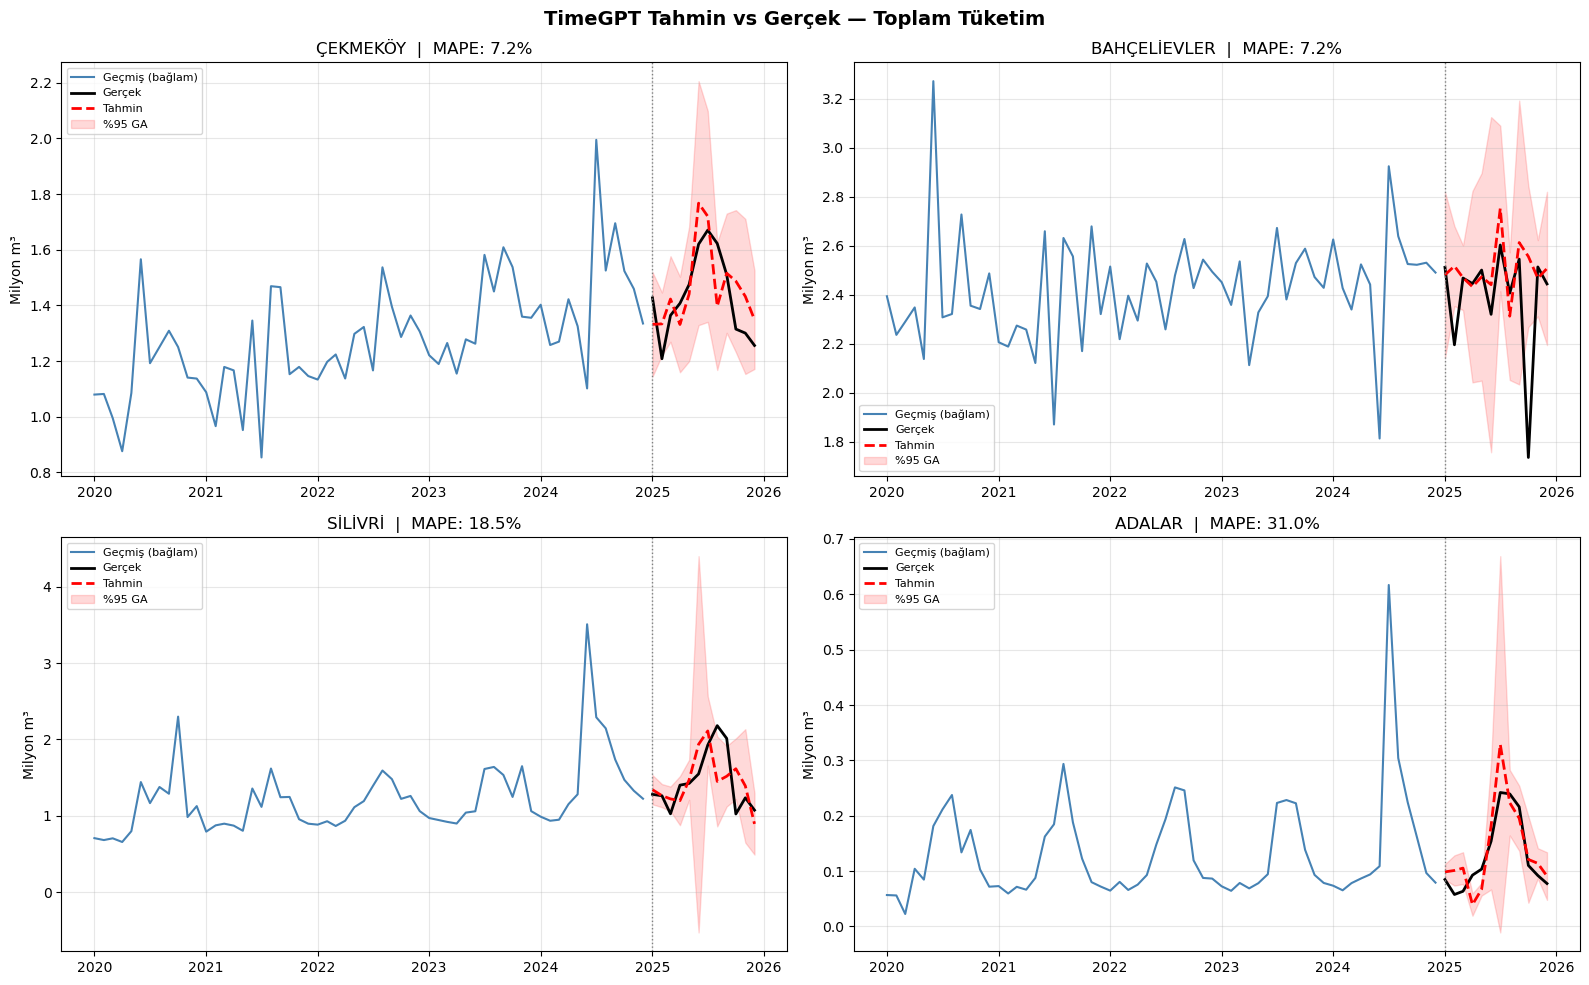

✅ Tahmin grafikleri kaydedildi: tahmin_grafikleri.png


In [99]:
# ── AŞAMA 18: TAHMİN GRAFİKLERİ ────────────────────────────
en_iyi  = metrikler.head(2)["unique_id"].tolist()
en_kotu = metrikler.tail(2)["unique_id"].tolist()
gosterilecek = en_iyi + en_kotu

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("TimeGPT Tahmin vs Gerçek — Toplam Tüketim", fontsize=14, fontweight="bold")

for ax, ilce in zip(axes.flatten(), gosterilecek):
    gecmis = df_ctx_konut_tam[df_ctx_konut_tam["unique_id"] == ilce].copy()
    gecmis_isyeri = df_ctx_isyeri_tam[df_ctx_isyeri_tam["unique_id"] == ilce].copy()
    gecmis["toplam"] = gecmis["y"] + gecmis_isyeri["y"].values

    k = karsilastirma[karsilastirma["unique_id"] == ilce]
    mape_val = metrikler[metrikler["unique_id"] == ilce]["MAPE_Toplam"].values[0]

    ax.plot(gecmis["ds"], gecmis["toplam"] / 1e6,
            color="steelblue", linewidth=1.5, label="Geçmiş (bağlam)")
    ax.plot(k["ds"], k["toplam_gercek"] / 1e6,
            color="black", linewidth=2, label="Gerçek")
    ax.plot(k["ds"], k["toplam_tahmin"] / 1e6,
            color="red", linewidth=2, linestyle="--", label="Tahmin")
    ax.fill_between(k["ds"],
                    k["toplam_lo_95"] / 1e6,
                    k["toplam_hi_95"] / 1e6,
                    alpha=0.15, color="red", label="%95 GA")
    ax.axvline(pd.Timestamp("2025-01-01"), color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{ilce}  |  MAPE: {mape_val:.1f}%")
    ax.set_ylabel("Milyon m³")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tahmin_grafikleri.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tahmin grafikleri kaydedildi: tahmin_grafikleri.png")

In [100]:
# ── AŞAMA 19: SONUÇLARI EXCEL'E KAYDET ─────────────────────
CIKTI_DOSYASI = r"C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_timegpt.xlsx"

with pd.ExcelWriter(CIKTI_DOSYASI, engine="openpyxl") as writer:
    karsilastirma.to_excel(writer, sheet_name="Tahmin vs Gerçek",   index=False)
    metrikler.to_excel(    writer, sheet_name="Performans",          index=False)
    tahminler.to_excel(    writer, sheet_name="Tahminler",           index=False)
    df_ctx_konut_tam.to_excel( writer, sheet_name="Bağlam Konut",   index=False)
    df_ctx_isyeri_tam.to_excel(writer, sheet_name="Bağlam İşyeri",  index=False)
    df.to_excel(           writer, sheet_name="Ham Veri",            index=False)

print(f"✅ Excel kaydedildi: {CIKTI_DOSYASI}")
print("\n🎉 Tüm işlem tamamlandı!")

✅ Excel kaydedildi: C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_timegpt.xlsx

🎉 Tüm işlem tamamlandı!
